Importing required library and functions

In [1]:
import sys
import os
import re
import shutil
import psutil
import platform
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt;
import pyemu
import flopy
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
# herebedragons.py contains a series of utility functions that help us 
sys.path.insert(0,"..")
import herebedragons as hbd
from scipy.interpolate import griddata, RegularGridInterpolator
import skgstat as skg


Setting up MODFLOW files dir

Getting executables to run PEST

In [2]:
# folder containing original model files
org_d = os.path.join('..', '..', '..', "results", '3d_injection_modeling_PMW-6')

# a dir to hold a copy of the org model files
tmp_d = os.path.join('PMW-6_mf6')

if os.path.exists(tmp_d):
    shutil.rmtree(tmp_d)
shutil.copytree(org_d,tmp_d)

# get executables
hbd.prep_bins(tmp_d)
# get dependency folders
hbd.prep_deps(tmp_d)

In [3]:
sim_ws = os.path.join('..', '..', '..', "results", "3d_injection_modeling_PMW-6")
os.listdir(tmp_d)

['heads.csv',
 'inschek.exe',
 'k_layer1.txt',
 'k_layer2.txt',
 'k_layer3.txt',
 'mf5to6.exe',
 'mf6.exe',
 'mfsim.lst',
 'mfsim.nam',
 'MLAC-model.bud',
 'MLAC-model.chd',
 'MLAC-model.dis',
 'MLAC-model.dis.grb',
 'MLAC-model.hds',
 'MLAC-model.ic',
 'MLAC-model.ims',
 'MLAC-model.lst',
 'MLAC-model.nam',
 'MLAC-model.npf',
 'MLAC-model.obs',
 'MLAC-model.oc',
 'MLAC-model.sto',
 'MLAC-model.tdis',
 'MLAC-model.wel',
 'mp7.exe',
 'pest.exe',
 'pestchek.exe',
 'pestpp-da.exe',
 'pestpp-glm.exe',
 'pestpp-ies.exe',
 'pestpp-mou.exe',
 'pestpp-opt.exe',
 'pestpp-sen.exe',
 'pestpp-swp.exe',
 'simulated_data',
 'tempchek.exe',
 'well_location_and_times.csv',
 'zbud6.exe']

Loading MODFLOW simulation to obtain discretization information

In [4]:
sim = flopy.mf6.MFSimulation.load(sim_ws=tmp_d)
gwf = sim.get_model()

#pyemu.os_utils.run("mf6", cwd=tmp_d, verbose=True)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


Spatial reference

In [5]:
#grid_length_x = gwf.dis.delr.array.sum()
grid_length_y = gwf.dis.delc.array.sum()
topleft_yorigin = gwf.dis.yorigin.array + grid_length_y
proj4 = '+proj=utm +zone=15 +datum=NAD83 +units=m +no_defs +type=crs'
sr = pyemu.helpers.SpatialReference(
    delr=gwf.dis.delr.array, 
    delc=gwf.dis.delc.array,
    xul=gwf.dis.xorigin.array, 
    yul=topleft_yorigin, 
    proj4_str=proj4,
)

Instantiate PstFrom

In [6]:
template_ws = os.path.join("PMW-6_template") #template directory (PstFrom working folder)
start_datetime = "08/29/2024"

#instantiate PstFrom
pf = pyemu.utils.PstFrom(
    original_d = tmp_d, #where the model is stored
    new_d = template_ws, #where the PEST template will be stored
    longnames = False, #for using PEST/PEST_HP
    spatial_reference = sr, #spatial reference from the model
    zero_based = False, #MODFLOW does not use zero based indices
    start_datetime = start_datetime, #for temporal correlation between parameters
    echo=True, 
    remove_existing=True, #remove existing files in the template directory
)

2025-11-18 13:05:15.972067 starting: opening PstFrom.log for logging
2025-11-18 13:05:15.972067 starting PstFrom process
2025-11-18 13:05:15.980611 starting: setting up dirs
2025-11-18 13:05:15.980611 starting: removing existing new_d 'PMW-6_template'
2025-11-18 13:05:16.169437 finished: removing existing new_d 'PMW-6_template' took: 0:00:00.188826
2025-11-18 13:05:16.169437 starting: copying original_d 'PMW-6_mf6' to new_d 'PMW-6_template'
2025-11-18 13:05:18.159271 finished: copying original_d 'PMW-6_mf6' to new_d 'PMW-6_template' took: 0:00:01.989834
2025-11-18 13:05:18.160658 finished: setting up dirs took: 0:00:02.180047


pf

Adjusting heads.csv file to match field data times

In [7]:
import flopy.utils.binaryfile as bf
"""
Reads the MODFLOW binary heads file, extracts heads for specified
observation wells at desired times, interpolating between time steps
if necessary, and saves the data to heads.csv.
"""

model_name = "MLAC-model"

file_path = os.path.join(template_ws, 'well_location_and_times.csv')

# --- Load observation info from the CSV file ---
try:
    obs_df = pd.read_csv(file_path)

except FileNotFoundError:
    raise FileNotFoundError("well_locations.csv not found. Did you run create_model.py?")

# Check if the .hds file exists before attempting to read
hds_filepath = os.path.join(template_ws, f'{model_name}.hds')
if not os.path.exists(hds_filepath):
    raise FileNotFoundError(f"Binary heads file not found: {hds_filepath}")

hds_file = bf.HeadFile(hds_filepath)
model_output_times = np.array(hds_file.get_times())

# Get the unique well names and locations
well_locations = obs_df[['well_name', 'layer', 'row', 'col']].drop_duplicates()

# Prepare results storage
interpolated_results = []

for index, obs in obs_df.iterrows():
    well_name = obs['well_name']
    layer, row, col = obs['layer'], obs['row'], obs['col']
    target_time = obs['time']

    # Find the time steps in the model output that bracket the target_time
    # Use np.searchsorted for efficient finding of insertion points
    idx = np.searchsorted(model_output_times, target_time)

    # Handle edge cases: target_time is before the first or after the last model output time
    if idx == 0:
        # Target time is at or before the first model output time.
        # Use the first time step's head.
        # You might want to raise a warning or handle this differently (e.g., extrapolation if allowed).
        t1 = model_output_times[0]
        heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
        interpolated_head = heads_data_t1
        print(f"Warning: Target time {target_time} is before or at first model time {t1}. Using head at {t1}.")

    elif idx == len(model_output_times):
        # Target time is at or after the last model output time.
        # Use the last time step's head.
        # You might want to raise a warning or handle this differently.
        t1 = model_output_times[-1]
        heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
        interpolated_head = heads_data_t1
        print(f"Warning: Target time {target_time} is at or after last model time {t1}. Using head at {t1}.")

    else:
        # Target time is between two model output times or exactly at one.
        t1 = model_output_times[idx - 1]
        t2 = model_output_times[idx]

        if target_time == t1:
            # Exact match for the lower bound
            heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
            interpolated_head = heads_data_t1
        elif target_time == t2:
            # Exact match for the upper bound
            heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]
            interpolated_head = heads_data_t2
        else:
            # Interpolate between t1 and t2
            heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
            heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]

            # Linear interpolation formula
            interpolated_head = heads_data_t1 + (heads_data_t2 - heads_data_t1) * \
                                (target_time - t1) / (t2 - t1)
    
    interpolated_results.append({
        'time': target_time,
        'well_name': f'HEAD_{well_name}',
        'head': interpolated_head
    })

# Create and pivot the DataFrame
results_df = pd.DataFrame(interpolated_results)

# Pivot the data to have columns for each well name
output_df = results_df.pivot(index='time', columns='well_name', values='head')

# Sort by time, reset index for clean CSV, and ensure consistent output column order
output_df = output_df.sort_index().reset_index()

desired_order = ['time', 'HEAD_PW-1', 'HEAD_PMW-3', 'HEAD_PMW-10', 'HEAD_PMW-14',
                    'HEAD_PW-2', 'HEAD_PMW-9', 'HEAD_PZ-1', 'HEAD_PMW-4', 'HEAD_PMW-5',
                    'HEAD_OW24P', 'HEAD_OW23P', 'HEAD_OW17P']

# Select the columns in the specified order
# Note: If a column is in desired_order but not in output_df, it will be added as NaN.
# If a column is in output_df but not in desired_order, it will be dropped.
try:
    output_df = output_df[desired_order]
except KeyError as e:
    print(f"Warning: A column was not found during reordering: {e}")
    # Continue saving, but without the specified order if it fails

# Write to CSV
output_df.to_csv(os.path.join(template_ws, 'heads.csv'), index=False, float_format='%.16E')
print("heads.csv created with interpolated head data at specified times.")

heads.csv created with interpolated head data at specified times.


Checking data from MODFLOW

In [8]:
#checking the output csv files
for i in [gwf.obs]: 
    print(i.output.obs_names)

['heads.csv']


taking a look at the data file

In [9]:
df_modflow = pd.read_csv(os.path.join(template_ws, "heads.csv"), index_col=0)
df_modflow.head()

,HEAD_PW-1,HEAD_PMW-3,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW-2,HEAD_PMW-9,HEAD_PZ-1,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P
time,,,,,,,,,,,,
0.010417,0.020916,0.082986,0.099070,0.067635,0.077078,0.019033,0.045098,0.009717,0.026818,0.026691,0.110870,0.016515
0.020833,0.046839,0.123527,0.140921,0.106017,0.116659,0.044048,0.079158,0.028729,0.056122,0.056204,0.154632,0.040597
0.041667,0.081487,0.166799,0.184479,0.147901,0.159087,0.078432,0.118614,0.058585,0.092631,0.092736,0.199044,0.074118
0.062500,0.103825,0.192060,0.209663,0.172646,0.183869,0.100882,0.142682,0.079221,0.115362,0.114763,0.224219,0.095499


Taking a look at the field data

In [10]:
df_field = pd.read_csv("../../../data/PMW-6_t.csv", index_col=0)
df_field.head()

,HEAD_PW-1,HEAD_PMW-3,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW-2,HEAD_PMW-9,HEAD_PZ-1,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P
time,,,,,,,,,,,,
0.010417,0.009313,0.139853,0.005000,0.110165,0.00136,0.000,0.019109,-0.002393,0.006000,0.003426,0.021026,0.005726
0.020833,0.035997,0.203853,0.028999,0.180839,-0.00022,-0.001,0.063277,0.005620,0.030998,0.009688,0.045382,0.016650
0.041667,0.123661,0.282903,0.109995,0.260987,-0.00391,0.001,0.149909,0.025665,0.096995,0.013416,0.075830,0.033832
0.062500,0.184743,0.329537,0.170992,0.307138,0.00139,0.003,0.197710,0.045378,0.147993,0.025560,0.094278,0.050680


Both have the same order of wells

In [11]:
df_modflow.columns.values == df_field.columns.values

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

copying over the field data to our template folder. starting heads.csv will be the field data that will be used to add observation data in the PEST control file. during the PEST iterations, MODFLOW + processing code will overwrite this file with the current iteration simulation output. 

In [12]:
shutil.copy2(
    src="../../../data/PMW-6_t.csv",
    dst=os.path.join(template_ws, "heads.csv")
)

shutil.copy(
    src="../../../data/PMW-6_t.csv",
    dst=os.path.join(template_ws, "PMW-6_t.csv")
)

'PMW-6_template\\PMW-6_t.csv'

Adding field observation to pst

In [13]:
hds_df = pf.add_observations(
    "heads.csv", #data file to read
    insfile="heads.csv.ins", #instruction file name
    index_cols="time", #column header to use as index
    use_cols=list(df_field.columns.values), #name of columns that includes observation values
    #prefix="hds" #prefix to all observation names
    #obsnam_dict={"head_pw1": "pw1"}
)

2025-11-18 13:05:32.720377 starting: adding observations from output file heads.csv
2025-11-18 13:05:32.721377 starting: adding observations from tabular output file '['heads.csv']'
2025-11-18 13:05:32.721377 starting: reading list-style file: PMW-6_template\heads.csv
2025-11-18 13:05:32.727601 finished: reading list-style file: PMW-6_template\heads.csv took: 0:00:00.006224
2025-11-18 13:05:32.729598 starting: building insfile for tabular output file heads.csv
2025-11-18 13:05:32.731738 finished: building insfile for tabular output file heads.csv took: 0:00:00.002140
2025-11-18 13:05:32.731738 starting: adding observation from instruction file 'PMW-6_template\heads.csv.ins'
2025-11-18 13:05:32.745931 finished: adding observation from instruction file 'PMW-6_template\heads.csv.ins' took: 0:00:00.014193
2025-11-18 13:05:32.747931 finished: adding observations from tabular output file '['heads.csv']' took: 0:00:00.026554
2025-11-18 13:05:32.747931 finished: adding observations from output

In [14]:
hds_df.head()

,obsnme,obsval,weight,obgnme
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,0.005726,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,0.016650,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,0.033832,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,0.050680,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,0.021026,1.0,oname:heads.csv_otype:lst_usecol:head_ow23p


instruction  file has been created in the template folder

In [15]:
[f for f in os.listdir(template_ws) if f.endswith(".ins")]

['heads.csv.ins']

Currently MODFLOW model has no idomain which will be used to inactivate some cells above the below BPP to simulate the packer. Since the current model only has 3 layers, I am not inactivating it yet, so we can collect data above the BPP

In [16]:
#get the IDOMAIN array
ib = gwf.dis.idomain.array[0]

plt.imshow(ib)
plt.colorbar()

TypeError: 'NoneType' object is not subscriptable

Geostatistical structures for interpolation from pp to model grid

Currently for layer 1 and 3:
* Range = 200 m
* Sill = 1.0
* Nugget = 0.0
* Isotropic

for layer 2 (BPP): 
* Range = 50 m
* Sill = 1.0
* Nugget = 0.0
* Isotropic

In [16]:
#exponential variogram for spatially varying parameters
v_pp = pyemu.geostats.ExpVario(
    contribution=1.0, #sill
    a=200, #range of correlation in meters
    anisotropy=1.0, 
    bearing=0.0, #angle in degrees East to North  corresponding to anisotropy ellipse
)

#geostatiscal structure for spatially varying parameters
pp_gs = pyemu.geostats.GeoStruct(variograms=v_pp, transform='log')

#plotting
#ax = pp_gs.plot()

In [17]:
#exponential variogram for spatially varying parameters
v_pp_2 = pyemu.geostats.ExpVario(
    contribution=1.0, #sill
    a=50, #range of correlation in meters
    anisotropy=1.0, 
    bearing=0.0, #angle in degrees East to North  corresponding to anisotropy ellipse
)

#geostatiscal structure for spatially varying parameters
pp_gs_2 = pyemu.geostats.GeoStruct(variograms=v_pp_2, transform='log')

Adding the parameters to layer 0: pilot points grid

In [18]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
ib0 = gwf.dis.idomain.array[0]
plt.imshow(ib)

TypeError: 'NoneType' object is not subscriptable

adding pilot points layer 1

In [18]:
df_pp1 = pf.add_parameters(
    'k_layer1.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer1", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells
    geostruct=pp_gs, #geostructure of the pilot points for interpolating to model grid
    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space=70 #one pp every 70 cells
)

2025-11-18 13:07:20.489323 transform was not passed, setting default transform to 'log'
2025-11-18 13:07:20.489323 starting: adding pilotpoints type m style parameters for file(s) ['k_layer1.txt']
2025-11-18 13:07:20.489323 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:200.0,anisotropy:1.0,bearing:0.0

2025-11-18 13:07:20.489323 starting: loading array PMW-6_template\k_layer1.txt
2025-11-18 13:07:20.546729 finished: loading array PMW-6_template\k_layer1.txt took: 0:00:00.057406
2025-11-18 13:07:20.546729 loaded array 'PMW-6_mf6\k_layer1.txt' of shape (388, 388)
2025-11-18 13:07:20.744799 starting: writing array-style template file 'PMW-6_template\k_layer1_inst0_pilotpoints.csv.tpl'
2025-11-18 13:07:20.745801 starting: setting up pilot point parameters
2025-11-18 13:07:20.745801 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-11-18 13:07:20.745801 'use_pp

In [19]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


Importing packer data for layer 1

In [20]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr1 = df_packers[df_packers['layer'] == 1]
lyr1 = lyr1.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr1 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),source,notes
0,PW-1,4980066,480869,1,0.15638,"packer test (PEER, 1999)",NaN
3,PW-2,4980048,480794,1,17.62560,"packer test (PEER, 1999)",average between 15.984 and 19.2672
6,PZ-2,4980037,480808,1,12.09600,"packer test (PEER, 1999)",does not seem accurate/reliable
21,94-10,4979932,480805,1,0.34311,"packer test (CNA, 1997)",NaN
24,94-11,4980004,480833,1,16.68270,"packer test (CNA, 1997)",NaN
27,94-16,4979933,480730,1,18.18656,"packer test (CNA, 1997)",NaN


Interpolating prior data (pakcer data) to pilot points data

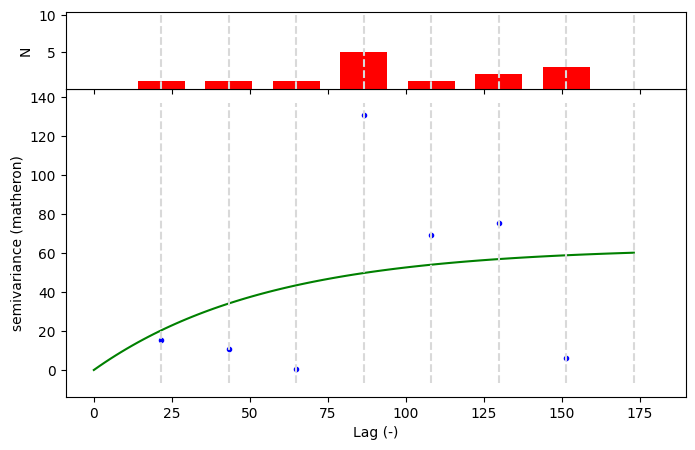

In [21]:
V1 = skg.Variogram(
    lyr1[['easting', 'northing']].values, 
    lyr1['Kh (m/day)'].values.flatten(), 
    maxlag=0.9, 
    n_lags=8, 
    normalize=False, 
    model='exponential'
    )

fig = V1.plot()

In [23]:
print(f"the correlation length based on the automatic data (poor) fitting is: {V1.describe()['effective_range']} meters")

the correlation length based on the automatic data (poor) fitting is: 166.11090288613792 meters


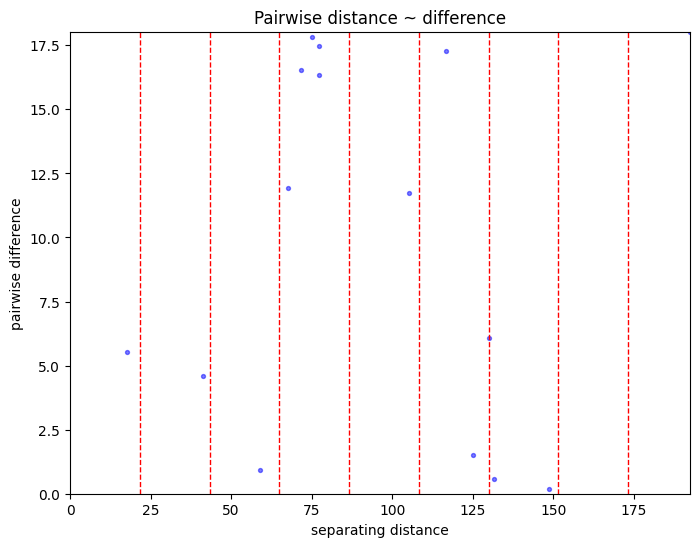

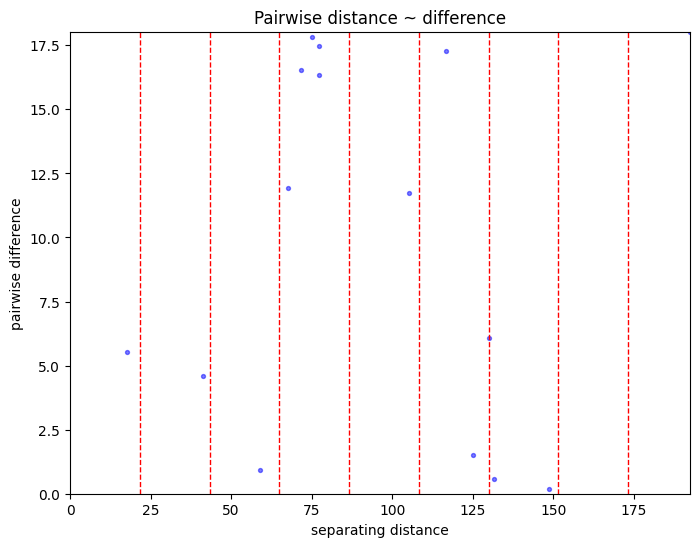

In [22]:
V1.distance_difference_plot(show=False)

In [23]:
ok1 = skg.OrdinaryKriging(V1, min_points=1, mode='exact')
x = lyr1[['easting', 'northing']].values[:, 0]
y = lyr1[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field1 = ok1.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok1.sigma.reshape(xx.shape)

In [24]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field1, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords1 = np.column_stack([df_pp1['x'].values, df_pp1['y'].values])
sampled_values1 = interpolator(sample_coords1)

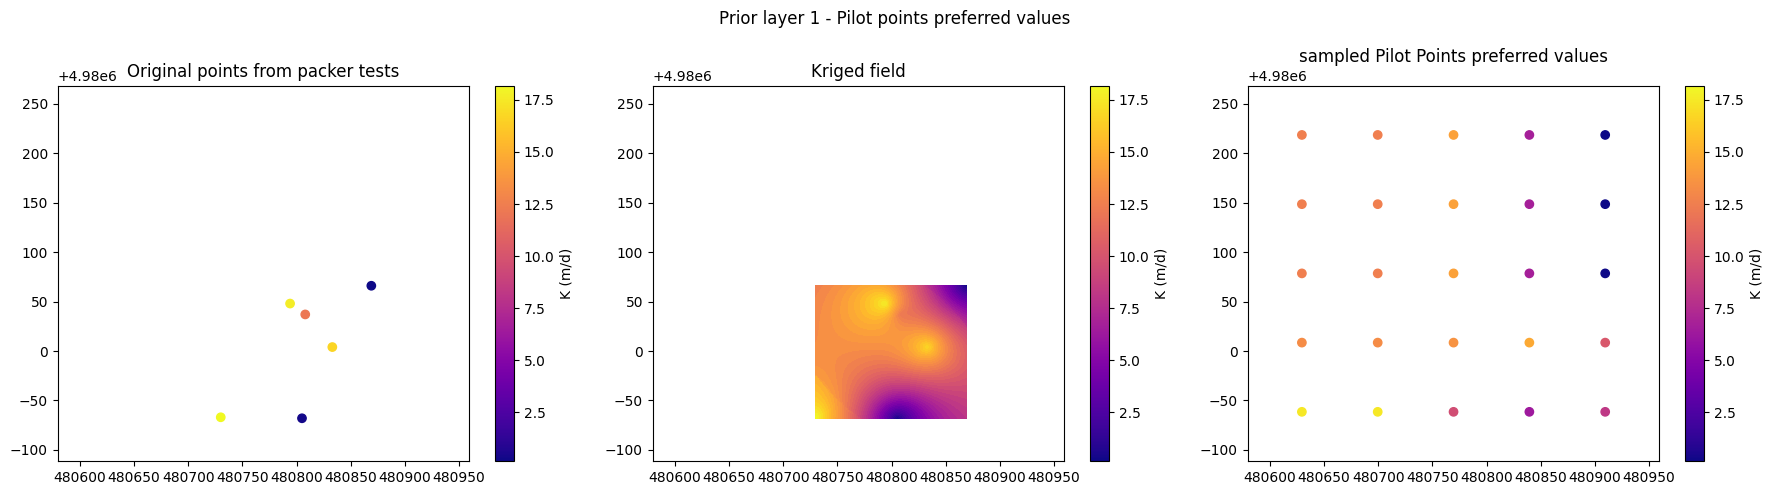

In [25]:
x_min, x_max = df_pp1['x'].min() - 50, df_pp1['x'].max() + 50
y_min, y_max = df_pp1['y'].min() - 50, df_pp1['y'].max() + 50

vmin = min(lyr1['Kh (m/day)'].min(), field1.min(), sampled_values1.min())
vmax = max(lyr1['Kh (m/day)'].max(), field1.max(), sampled_values1.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr1['easting'], lyr1['northing'], 
    c=lyr1['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field1.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp1['x'], df_pp1['y'], 
    #c=df_pp1['parval1'], 
    c=sampled_values1, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 1 - Pilot points preferred values')

plt.tight_layout()
plt.show()

asserting pilot point file was created

In [26]:
pp1_file = os.path.join(template_ws, "k_layer1_inst0pp.dat")
assert os.path.exists(pp1_file)

In [27]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


updating initial value + parameter bounds based on prior data uncertainty

In [28]:
df_pp1['parval1'] = sampled_values1
par_bnd_len = np.std(np.log(lyr1['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp1['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp1['parval1'].values) + (par_bnd_len/2)
df_pp1['parlbnd'] = 10**parlbnd
df_pp1['parubnd'] = 10**parubnd

In [29]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,12.543329,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.031977,log,3.577192e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,12.543329,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.031977,log,3.577192e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,14.245595,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.042864,log,4.795136e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,6.692150,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.007526,log,8.419539e+05,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,0.156380,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.000001,log,1.475322e+02,1.0,pilotpoints


In [30]:
len(df_pp1)

25

pilot points locations

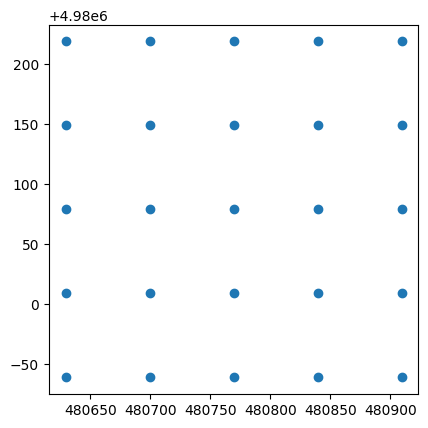

In [31]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
#ax.pcolormesh(sr.xcentergrid, sr.ycentergrid, ib)
ax.scatter(df_pp1.x, df_pp1.y)

adding parameter to layer 2 (BPP): constant K for now

In [32]:
df_pp2 = pf.add_parameters(
    'k_layer2.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer2", 
    #pargp="pg2", 
    #zone_array=ib, #to be added when inactivating some cells

    geostruct=pp_gs_2, #geostructure of the pilot points #for interpolate from pp to model grid 
    #USING THE SAME STRUCTURE AS LAYER 1 (ABOVE BPP)

    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space='C:/Users/lima0055/Documents/MLAC-3D-HT/data/pilot-points-v1.shp', 
    )

2025-11-18 13:08:17.065304 transform was not passed, setting default transform to 'log'
2025-11-18 13:08:17.065304 starting: adding pilotpoints type m style parameters for file(s) ['k_layer2.txt']
2025-11-18 13:08:17.065304 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:50.0,anisotropy:1.0,bearing:0.0

2025-11-18 13:08:17.066307 starting: loading array PMW-6_template\k_layer2.txt
2025-11-18 13:08:17.125975 finished: loading array PMW-6_template\k_layer2.txt took: 0:00:00.059668
2025-11-18 13:08:17.125975 loaded array 'PMW-6_mf6\k_layer2.txt' of shape (388, 388)
2025-11-18 13:08:17.241115 starting: writing array-style template file 'PMW-6_template\k_layer2_inst0_pilotpoints.csv.tpl'
2025-11-18 13:08:17.241115 starting: setting up pilot point parameters
2025-11-18 13:08:17.241115 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-11-18 13:08:17.241115 'use_pp_

In [33]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,dercom,parchglim,offset,scale
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,factor,0.0,1.0


In [34]:
columns_to_export = ['name', 'x', 'y', 'zone', 'parval1'] 
df_pp2_subset = df_pp2[columns_to_export]

df_pp2_subset.to_csv(
    os.path.join(template_ws, 'k_layer2_inst0pp.dat'), 
    sep=' ',          #space delimiter
    index=False,
    header=False
)

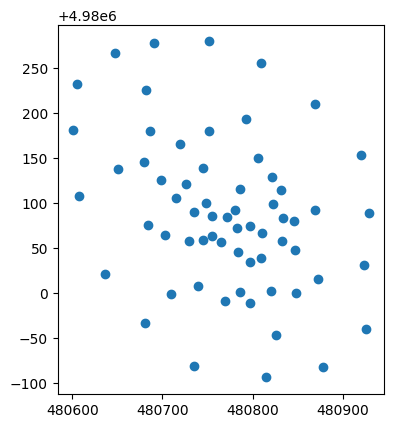

In [35]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
#ax.pcolormesh(sr.xcentergrid, sr.ycentergrid, ib)
ax.scatter(df_pp2.x, df_pp2.y)

importing packer + slug test data for layer 2 (BPP)

In [36]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr2 = df_packers[df_packers['layer'] == 2]
lyr2 = lyr2.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr2 = lyr2.drop(7) #dropping PZ-2, data not reliable
lyr2 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),source,notes
1,PW-1,4980066,480869,2,9.158400,"packer test (PEER, 1999)",NaN
4,PW-2,4980048,480794,2,24.969600,"packer test (PEER, 1999)",NaN
10,94-02,4980038,480890,2,7.092215,"packer test (CNA, 1997)","average between (6.46046, 7.72397)"
13,94-07,4980198,480782,2,26.408272,"packer test (CNA, 1997)","average between (18.10218, 28.69549, 38.02080, 20.81462)"
16,94-08,4979864,480711,2,30.443695,"packer test (CNA, 1997)","average between (24.31918, 36.56821)"
19,94-09,4979900,480919,2,23.326910,"packer test (CNA, 1997)",NaN
22,94-10,4979932,480805,2,51.195490,"packer test (CNA, 1997)",NaN
25,94-11,4980004,480833,2,16.897960,"packer test (CNA, 1997)",NaN
28,94-16,4979933,480730,2,12.193260,"packer test (CNA, 1997)",NaN
30,OW24P,4980200,480646,2,8.490000,Slug test 2025,NaN


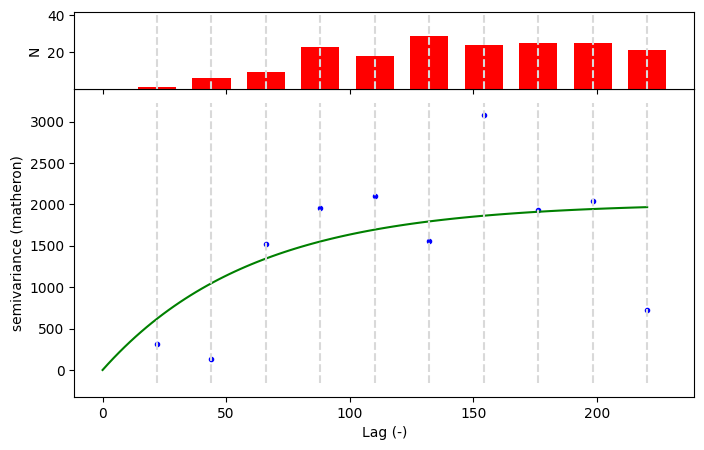

In [37]:
V2 = skg.Variogram(
    lyr2[['easting', 'northing']].values, 
    lyr2['Kh (m/day)'].values.flatten(), 
    maxlag=0.5, 
    n_lags=10, 
    normalize=False, 
    model='exponential'
    )

fig = V2.plot()

In [38]:
print(f"the correlation length based on the automatic data (poor) fitting is: {V2.describe()['effective_range']} meters")

the correlation length based on the automatic data (poor) fitting is: 180.40688886550828 meters


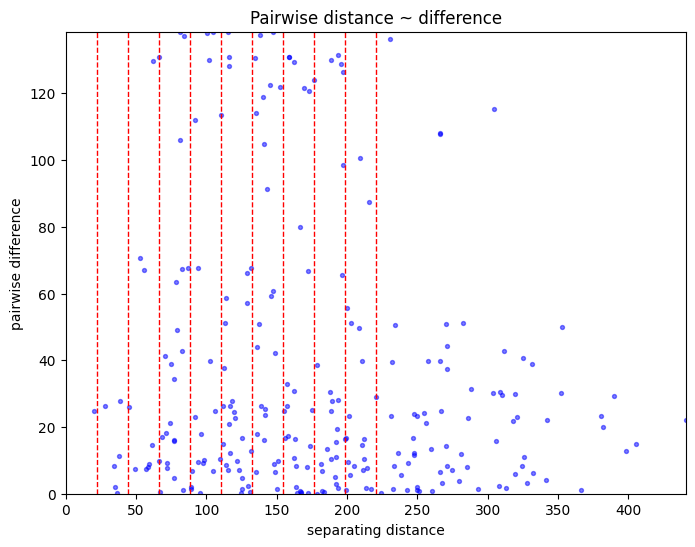

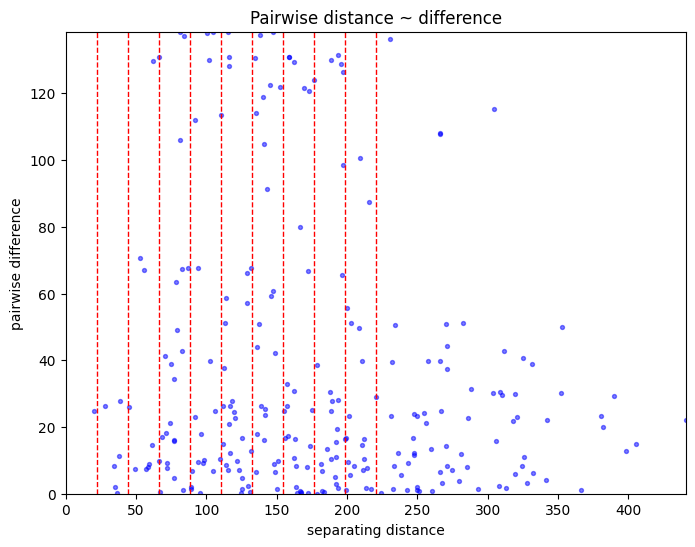

In [39]:
V2.distance_difference_plot(show=False)

In [40]:
ok2 = skg.OrdinaryKriging(V2, min_points=1, mode='exact')
x = lyr2[['easting', 'northing']].values[:, 0]
y = lyr2[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field2 = ok2.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok2.sigma.reshape(xx.shape)

In [41]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field2, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords2 = np.column_stack([df_pp2['x'].values, df_pp2['y'].values])
sampled_values2 = interpolator(sample_coords2)

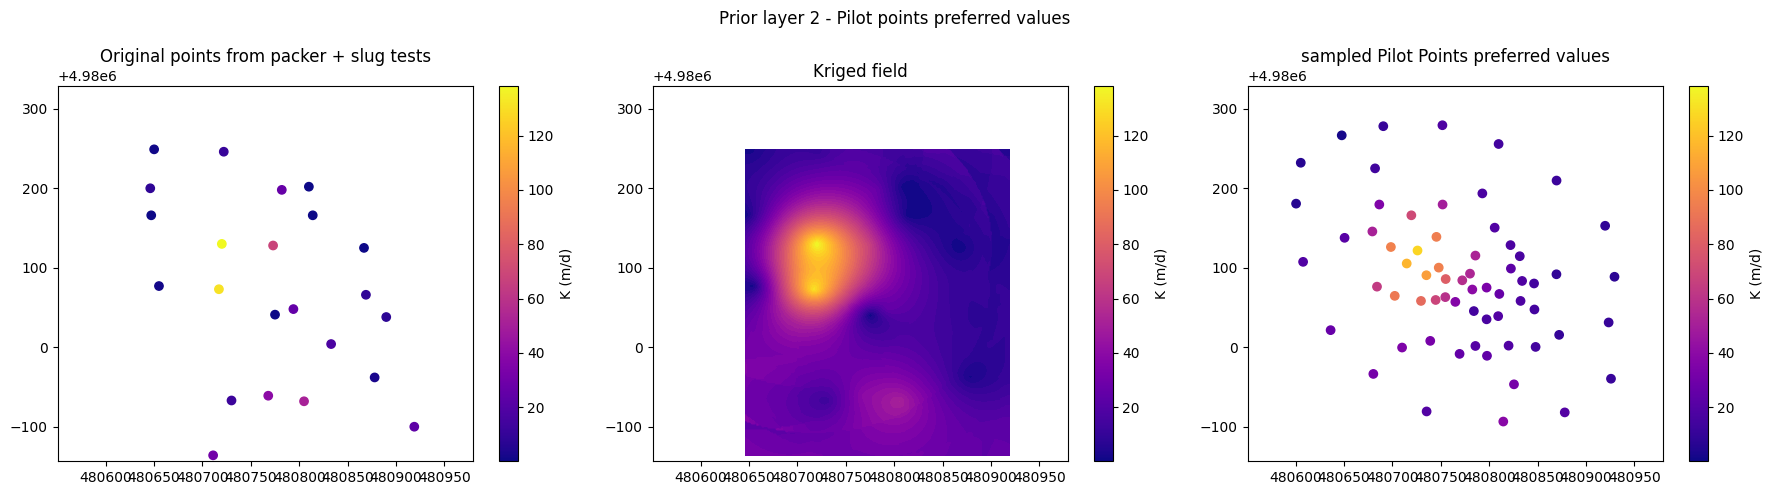

In [42]:
x_min, x_max = df_pp2['x'].min() - 50, df_pp2['x'].max() + 50
y_min, y_max = df_pp2['y'].min() - 50, df_pp2['y'].max() + 50

vmin = min(lyr2['Kh (m/day)'].min(), field2.min(), sampled_values2.min())
vmax = max(lyr2['Kh (m/day)'].max(), field2.max(), sampled_values2.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr2['easting'], lyr2['northing'], 
    c=lyr2['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer + slug tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field2.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp2['x'], df_pp2['y'], 
    #c=df_pp2['parval1'], 
    c=sampled_values2, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 2 - Pilot points preferred values')

plt.tight_layout()
plt.show()

In [43]:
pp2_file = os.path.join(template_ws, "k_layer2_inst0pp.dat")
assert os.path.exists(pp2_file)

In [44]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,dercom,parchglim,offset,scale
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,factor,0.0,1.0


In [45]:
df_pp2['parval1'] = sampled_values2
par_bnd_len = np.std(np.log(lyr2['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp2['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp2['parval1'].values) + (par_bnd_len/2)
df_pp2['parlbnd'] = 10**parlbnd
df_pp2['parubnd'] = 10**parubnd
df_pp2['zone'] = 2

In [46]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,dercom,parchglim,offset,scale
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,19.826192,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,4.670220e+07,0.020168,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,14.812540,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,2.386753e+07,0.010307,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,33.664290,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.580415e+08,0.068250,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,14.317778,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,2.207168e+07,0.009532,1,factor,0.0,1.0
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,9.279817,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,8.131586e+06,0.003512,1,factor,0.0,1.0


In [47]:
len(df_pp2)

64

Adding parameter to layer 3: pilot points

In [35]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
ib3 = gwf.dis.idomain.array[2]
plt.imshow(ib3)

TypeError: 'NoneType' object is not subscriptable

In [48]:
df_pp3 = pf.add_parameters(
    'k_layer3.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer3", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells

    geostruct=pp_gs, #geostructure of the pilot points #for interpolate from pp to model grid 
    #USING THE SAME STRUCTURE AS LAYER 1 (ABOVE BPP)

    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space=70
)

2025-11-18 13:09:34.639865 transform was not passed, setting default transform to 'log'
2025-11-18 13:09:34.639865 starting: adding pilotpoints type m style parameters for file(s) ['k_layer3.txt']
2025-11-18 13:09:34.640820 finished: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:200.0,anisotropy:1.0,bearing:0.0
 took: 0:02:14.151497
2025-11-18 13:09:34.640820 starting: loading array PMW-6_template\k_layer3.txt
2025-11-18 13:09:34.716989 finished: loading array PMW-6_template\k_layer3.txt took: 0:00:00.076169
2025-11-18 13:09:34.716989 loaded array 'PMW-6_mf6\k_layer3.txt' of shape (388, 388)
2025-11-18 13:09:34.896590 starting: writing array-style template file 'PMW-6_template\k_layer3_inst0_pilotpoints.csv.tpl'
2025-11-18 13:09:34.896590 starting: setting up pilot point parameters
2025-11-18 13:09:34.896590 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-11-18 13

In [49]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


Importing packer test data for layer 3

In [50]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr3 = df_packers[df_packers['layer'] == 3]
lyr3 = lyr3.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr3 = lyr3.drop(8) #dropping PZ-2, data not reliable
lyr3 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),source,notes
2,PW-1,4980066,480869,3,0.042080,"packer test (PEER, 1999)",NaN
11,94-02,4980038,480890,3,0.209863,"packer test (CNA, 1997)","average between (0.37042, 0.17790, 0.15445, 0.13668)"
14,94-07,4980198,480782,3,0.237867,"packer test (CNA, 1997)","average between (0.27337, 0.23365, 0.20658)"
17,94-08,4979864,480711,3,0.288900,"packer test (CNA, 1997)","average between (0.30866, 0.42640, 0.13164)"
20,94-09,4979900,480919,3,3.274515,"packer test (CNA, 1997)","average between (12.30757, 0.22225, 0.19762, 0.37062)"
23,94-10,4979932,480805,3,0.149703,"packer test (CNA, 1997)","average between (0.16944, 0.14803, 0.13164)"
26,94-11,4980004,480833,3,0.879843,"packer test (CNA, 1997)","average between (0.07402, 1.01561, 1.54990)"
29,94-16,4979933,480730,3,0.458860,"packer test (CNA, 1997)","average between (1.51673, 0.11113, 0.10162, 0.10596)"


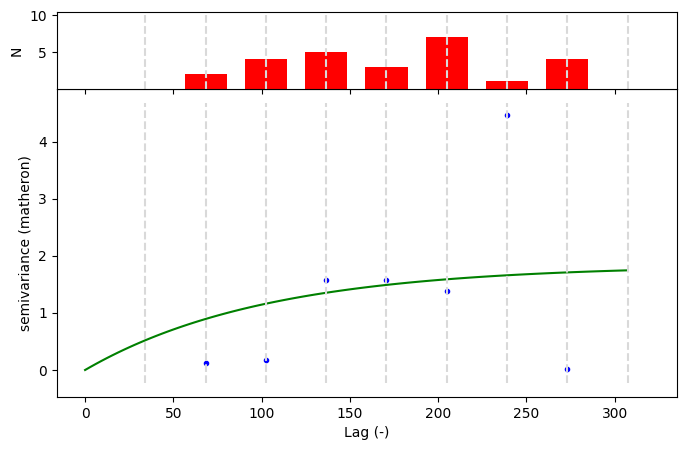

In [51]:
V3 = skg.Variogram(
    lyr3[['easting', 'northing']].values, 
    lyr3['Kh (m/day)'].values.flatten(), 
    maxlag=0.9, 
    n_lags=9, 
    normalize=False, 
    model='exponential'
    )

fig = V3.plot()

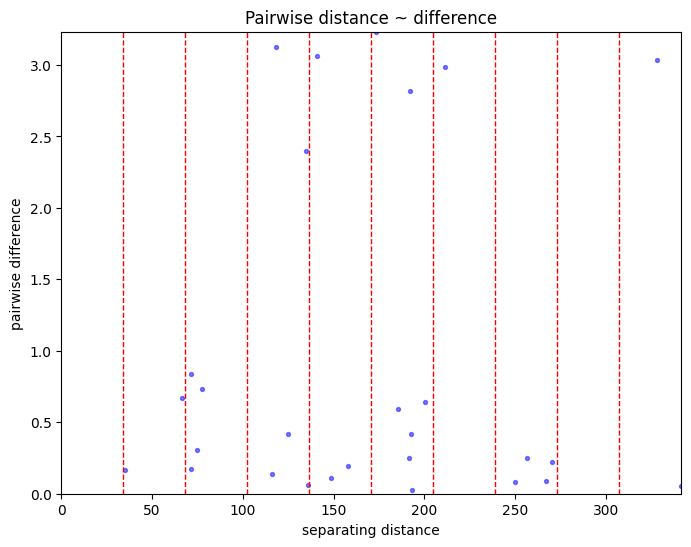

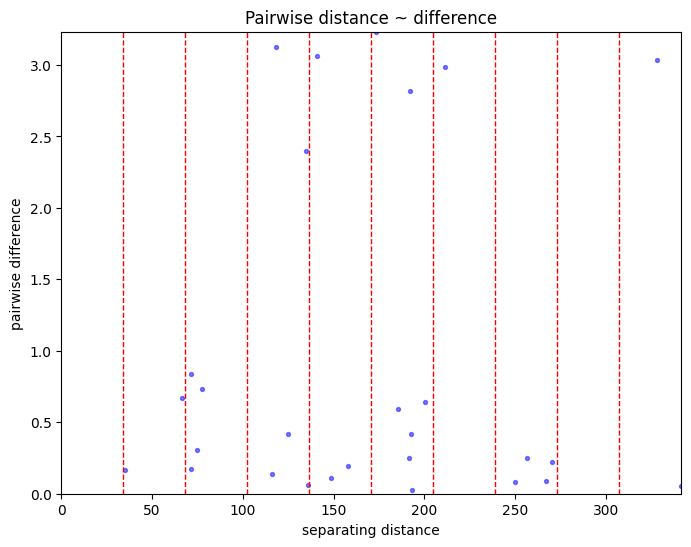

In [52]:
V3.distance_difference_plot(show=False)

In [53]:
print(f"the correlation length for layer 3 based on the packer test data is: {V3.describe()['effective_range']}")

the correlation length for layer 3 based on the packer test data is: 307.31672587088383


In [54]:
ok3 = skg.OrdinaryKriging(V3, min_points=1, mode='exact')
x = lyr3[['easting', 'northing']].values[:, 0]
y = lyr3[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field3 = ok3.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok3.sigma.reshape(xx.shape)

In [55]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field3, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords3 = np.column_stack([df_pp3['x'].values, df_pp3['y'].values])
sampled_values3 = interpolator(sample_coords3)

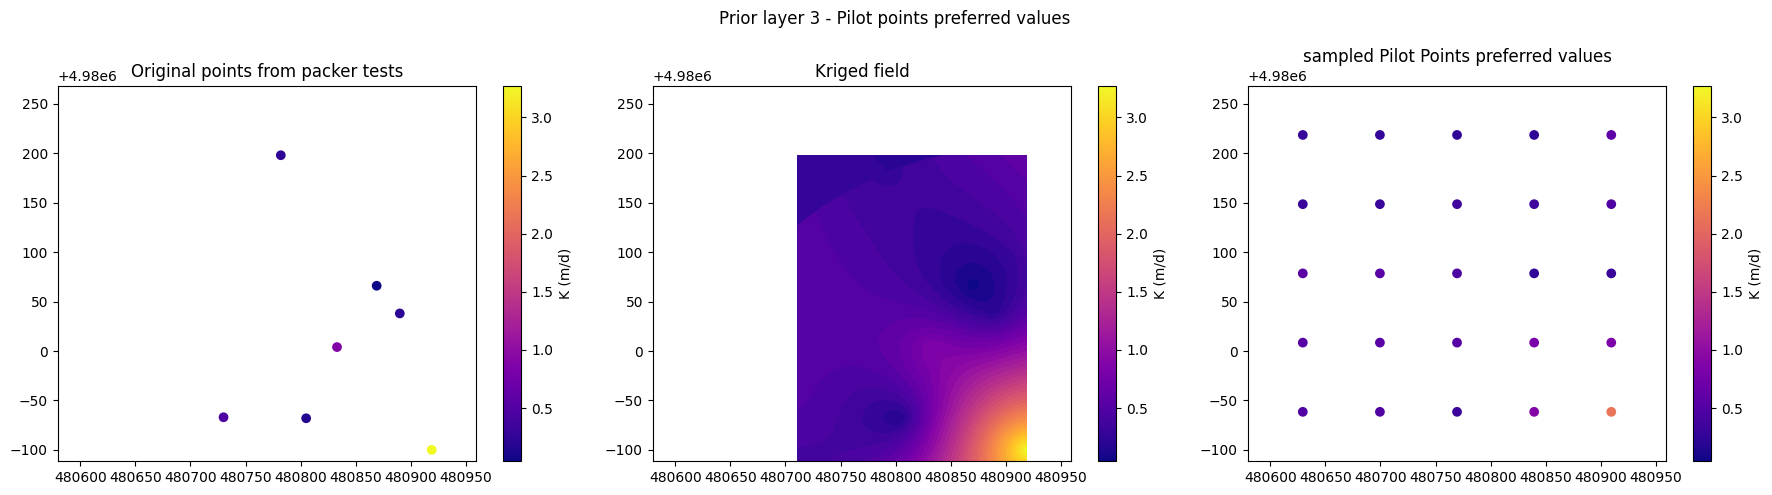

In [56]:
x_min, x_max = df_pp1['x'].min() - 50, df_pp1['x'].max() + 50
y_min, y_max = df_pp1['y'].min() - 50, df_pp1['y'].max() + 50

vmin = min(lyr3['Kh (m/day)'].min(), field3.min(), sampled_values3.min())
vmax = max(lyr3['Kh (m/day)'].max(), field3.max(), sampled_values3.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr3['easting'], lyr3['northing'], 
    c=lyr3['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field3.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp1['x'], df_pp1['y'], 
    #c=df_pp1['parval1'], 
    c=sampled_values3, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 3 - Pilot points preferred values')

plt.tight_layout()
plt.show()

In [57]:
pp3_file = os.path.join(template_ws, "k_layer1_inst0pp.dat")
assert os.path.exists(pp3_file)

updating layer index, initial value, and pilot points parameter bounds

In [58]:
df_pp3['k'] = 2
df_pp3['parval1'] = sampled_values3
par_bnd_len = np.std(np.log(lyr3['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp3['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp3['parval1'].values) + (par_bnd_len/2)
df_pp3['parlbnd'] = 10**parlbnd
df_pp3['parubnd'] = 10**parubnd
df_pp3['zone'] = 3

In [59]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,3,0.281720,2,35,35,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000215,log,13.619634,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,3,0.281720,2,35,105,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000215,log,13.619634,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,3,0.248252,2,35,175,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000161,log,10.178738,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,3,0.224927,2,35,245,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000128,log,8.110130,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,3,0.589716,2,35,315,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.001177,log,74.626218,1.0,pilotpoints


Adding mf6 to the command script

In [60]:
pf.mod_sys_cmds.append("mf6") #do this only once
pf.mod_sys_cmds

['mf6']

adding the processing MODFLOW output in the PEST running script. 

This processing script reads the MODFLOW simulation output (heads for all well in all simulation time steps), and sample heads only for desired times (i.e. times that we have field data) using interpolation, then overwrites the heads.csv (MODFLOW output) used to compared with the observation data added to the PEST control file.

In [61]:
pf.add_py_function("helpers.py","process_heads_csv()",is_pre_cmd=False)

building pst

In [62]:
pst = pf.build_pst()

2025-11-18 13:10:16.675704 starting: Converting parameters to shortnames
2025-11-18 13:10:16.685741 starting: Renaming parameters for shortnames
2025-11-18 13:10:21.204613 finished: Renaming parameters for shortnames took: 0:00:04.518872
2025-11-18 13:10:21.246004 finished: Converting parameters to shortnames took: 0:00:04.570300
2025-11-18 13:10:21.246004 starting: Converting observations to shortnames
2025-11-18 13:10:21.246004 starting: Renaming observations for shortnames
2025-11-18 13:10:25.974944 finished: Renaming observations for shortnames took: 0:00:04.728940
2025-11-18 13:10:26.006552 finished: Converting observations to shortnames took: 0:00:04.760548
noptmax:0, npar_adj:114, nnz_obs:48
2025-11-18 13:10:26.050714 forward_run line:pyemu.os_utils.run(r'mf6')



checking parameter groups and data

In [63]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
pg1,pg1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg0,pg0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg2,pg2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


In [64]:
pst.parameter_data.sample(5)

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,longname,shortname,pglong,i,inst,j,pname,pstyle,ptype,x,y,zone
p56,p56,log,factor,52.311818,0.188317,4.360695e+08,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480785.73_y:4980115.33_zone:1,p56,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480785.73,4980115.33,1
p86,p86,log,factor,38.503851,0.092988,2.153236e+08,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480814.56_y:4979906.51_zone:1,p86,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480814.56,4979906.51,1
p1,p1,log,factor,12.543329,0.031977,3.577192e+06,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,p1,k_layer1_inst:0,35,0,105,k,m,pp,NaN,NaN,1
p53,p53,log,factor,116.129847,1.181342,2.735535e+09,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480714.71_y:4980105.35_zone:1,p53,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480714.71,4980105.35,1
p84,p84,log,factor,31.843710,0.060049,1.390507e+08,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480680.20_y:4979966.42_zone:1,p84,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480680.20,4979966.42,1


## checking phimlim for investigation of minimum phi

In [65]:
pst.reg_data.phimlim

'1.0e-10'

minimum phi should be equal to the number of non-zero weighted observations

THIS ASSUMES THAT ALL MODEL-TO-MEASUREMENT MISFIT IS DUE TO MEASUREMENT UNCERTAINTY. In practice model error usually plays a larger role

In [66]:
pst.nnz_obs

48

aasigning PHILIM equal to the number of non-zero weighted observations

In [57]:
pst.reg_data.phimlim = pst.nnz_obs
pst.reg_data.phimlim

48

When changing PHIMLIM, we must also change PHIMACCEPT. this is the level of acceptable "measurement objective function".

If PEST achieves PHIMLIM, it will then attempt to minimize the regularization objective function, whiilst maintaining the measurement objective function below PHIMACCEPT

In [67]:
#setting PHIMACCEPT 10% higher than PHIMLIM
pst.reg_data.phimaccept = float(pst.reg_data.phimlim) * 1.1
pst.reg_data.phimaccept

1.1000000000000001e-10

changing PESTMODE to regularization

In [68]:
pst.control_data.pestmode = 'regularization'
pst.control_data.pestmode

'regularization'

updating the maximum number of PEST iteration

In [69]:
pst.control_data.noptmax = 1
pst.control_data.noptmax

np.int32(1)

In [70]:
print(f'there are {pst.nobs} field observation')

there are 48 field observation


changing observation names to meet the PEST version 1 character limit

In [71]:
print('current observation names:')
pst.obs_names[:5]

current observation names:


['ob0', 'ob1', 'ob2', 'ob3', 'ob4']


Each observation group correspond to a well in a injection test. So observation in the same well (and zone) during the same injection test are grouped together

In [72]:
pst.observation_data.head()

,obsnme,obsval,weight,obgnme,longname,shortname,oglong,oname,otype,time,usecol
ob0,ob0,0.005726,1.0,obg0,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,ob0,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.010417,head
ob1,ob1,0.016650,1.0,obg0,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,ob1,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.020833,head
ob2,ob2,0.033832,1.0,obg0,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,ob2,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.041667,head
ob3,ob3,0.050680,1.0,obg0,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,ob3,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.0625,head
ob4,ob4,0.021026,1.0,obg1,oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,ob4,oname:heads.csv_otype:lst_usecol:head_ow23p,heads.csv,lst,0.010417,head


Checking input and output model files

In [73]:
pst.model_input_data

,pest_file,model_file
k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat
k_layer2_inst0pp.dat.tpl,k_layer2_inst0pp.dat.tpl,k_layer2_inst0pp.dat
k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat


In [74]:
pst.model_output_data

,pest_file,model_file
heads.csv.ins,heads.csv.ins,heads.csv


Adding priors

In [75]:
pst.prior_information #no prior info up to now

,pilbl,obgnme,equation,weight


In [76]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
pg1,pg1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg0,pg0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg2,pg2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


adding preferred-value equations, currently only for layer 1 and 2

In [77]:
#applying preferred value regularization on all parameters
pyemu.helpers.zero_order_tikhonov(
    pst, parbounds=True, #using parameter bounds to specify prior information equation weights
    par_groups=['pg0', 'pg1', 'pg2'], #adding preferred-value only for pp in layer 1 and 3
    ) #setting up preferred-value regularization in the pest control file


In [78]:
pst.prior_information.sample(5)

,pilbl,equation,obgnme,weight
pilbl,,,,
p64,p64,1.0 * log(p64) = 1.158072E+00,regulpg1,0.106784
p103,p103,1.0 * log(p103) = -5.158872E-01,regulpg2,0.208246
p38,p38,1.0 * log(p38) = 1.600321E+00,regulpg1,0.106784
p22,p22,1.0 * log(p22) = 9.800248E-01,regulpg0,0.124244
p83,p83,1.0 * log(p83) = 1.430056E+00,regulpg1,0.106784


In [96]:
pst.pestpp_options.pop('n_iter_base')
pst.pestpp_options.pop('n_iter_super')

KeyError: 'n_iter_base'

overwritting pst file

In [79]:
pst.write(os.path.join(template_ws, 'PMW-6_mf6.pst'),version=1)

noptmax:1, npar_adj:114, nnz_obs:48


setting up agents for running PEST in parallel

In [80]:
#number of cores availables
psutil.cpu_count(logical=False)

10

In [81]:
#setting the number of workers
num_workers = 7

In [82]:
#run-manager directory folder (where the manager will be running), 
#outcomes of PEST will be recorded here in a different location than template_ws to avoid mistakes
m_d = 'master_pp'

when running from jupyter notebook slow things down a lot, it is better as the model get complex to run from command lines which is faster and more efficient

Starting workers and running PEST

In [83]:
pyemu.os_utils.start_workers(template_ws, # folder which contains the "template" PEST dataset
                            'pestpp-glm', #PEST software version we want to run
                            'PMW-6_mf6.pst', #PEST control file 
                            num_workers=num_workers, #how many agents to deploy
                            worker_root='.', #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d, #manager directory where it will be running
                            verbose=True,
                            )

2025-11-18 13:11:17,143 - MainProcess - INFO - Reserved port 4308 for process 13944


master:pestpp-glm PMW-6_mf6.pst /h :4308 in master_pp
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4308 in .\worker_0
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4308 in .\worker_1
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4308 in .\worker_2
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4308 in .\worker_3
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4308 in .\worker_4
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4308 in .\worker_5
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4308 in .\worker_6


Running PEST #old

In [74]:
#pyemu.os_utils.run('pestpp-glm PMW-6_mf6.pst', cwd=template_ws, verbose=True)

run():pestpp-glm.exe PMW-6_mf6.pst


plotting results

In [84]:
df_obj = pd.read_csv(os.path.join(m_d, "PMW-6_mf6.iobj"),index_col=0)
# echo out the dataframe
df_obj

,model_runs_completed,total_phi,measurement_phi,regularization_phi,obg0,obg1,obg2,obg3,obg4,obg5,obg6,obg7,obg8,obg9,obg10,obg11,regulpg0,regulpg1,regulpg2
iteration,,,,,,,,,,,,,,,,,,,
0,0,0.300508,0.300508,4.589060e-16,0.002064,0.002586,0.006671,0.009189,0.087467,0.110483,0.001492,0.007969,0.012612,0.016060,0.025164,0.018751,1.529690e-16,1.529690e-16,1.529690e-16
1,130,0.298721,0.298403,3.183460e-04,0.002106,0.002556,0.006864,0.009146,0.086371,0.108745,0.001499,0.008105,0.012901,0.015974,0.025384,0.018751,5.332550e-06,2.337700e-06,3.106760e-04


array([<Axes: xlabel='iteration'>, <Axes: xlabel='iteration'>],
      dtype=object)

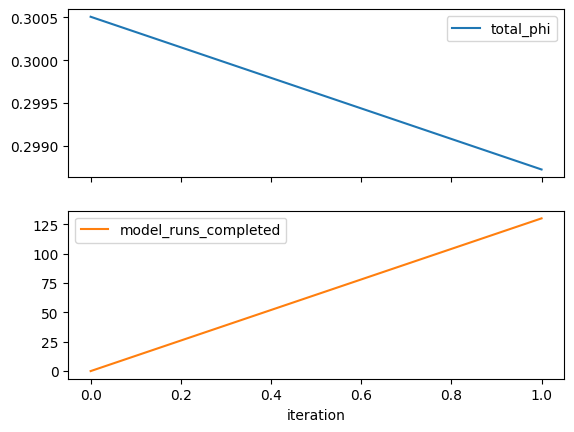

In [85]:
df_obj.loc[:,["total_phi","model_runs_completed"]].plot(subplots=True)

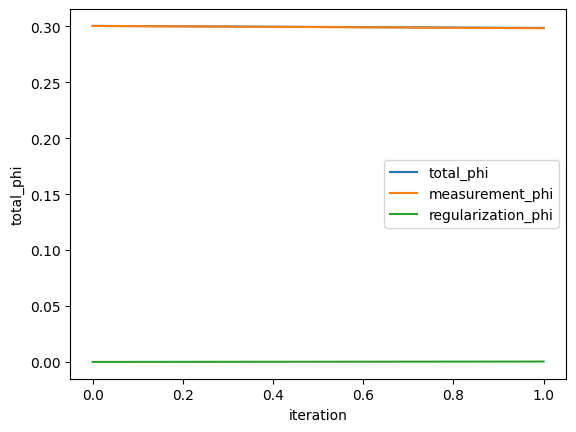

In [86]:
df_obj.plot(y=['total_phi','measurement_phi','regularization_phi'])
plt.ylabel('total_phi');

loading pst

In [87]:
pst = pyemu.Pst(os.path.join(m_d, 'PMW-6_mf6.pst'))

In [88]:
pst.phi

np.float64(0.29840258761896993)

Estimated K values:

In [89]:
pst.parrep(os.path.join(m_d, "PMW-6_mf6.par" ))
pst.write_input_files(pst_path=m_d)
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer1_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer1.txt"))

Updating parameter values from master_pp\PMW-6_mf6.par
parrep: updating noptmax to 0


'master_pp\\k_layer1.txt'

Only run for layer 2 when having pilot points

In [90]:
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer2_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer2_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer2.txt"))

'master_pp\\k_layer2.txt'

In [91]:
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer3_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer3.txt"))

'master_pp\\k_layer3.txt'

In [92]:
pst.parameter_data.parval1

parnme
p0       11.915925
p1       10.735194
p2       12.607959
p3        7.164439
p4        0.162961
p5       13.051260
p6       12.891153
p7       12.873517
p8        6.972144
p9        0.156510
p10      12.267469
p11      11.989841
p12      14.081107
p13       6.273197
p14       0.154806
p15      16.621797
p16      10.513470
p17      12.713197
p18      15.858880
p19      12.494614
p20      20.275307
p21      17.416108
p22      10.197293
p23       6.004501
p24       8.135680
p25      19.893879
p26      13.120843
p27      33.636114
p28      14.309959
p29       9.172886
p30      18.611002
p31      18.128675
p32      14.473838
p33      26.097398
p34      14.699238
p35      36.697772
p36      80.624412
p37     128.569978
p38      39.619507
p39      23.088044
p40      22.456153
p41      53.797350
p42      53.430170
p43      57.405591
p44      79.240417
p45      83.503278
p46      93.291745
p47      85.109626
p48      79.730589
p49      66.468234
p50      97.462816
p51      70.107483
p52  

In [93]:
import seaborn as sns

<Axes: >

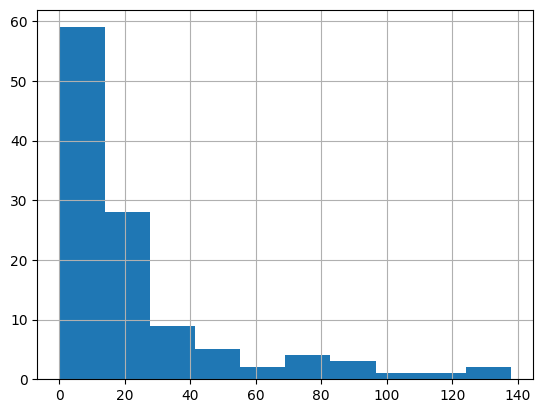

In [94]:
pst.parameter_data.parval1.hist()

In [95]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,extra,longname,i,inst,j,pname,pstyle,ptype,x,y,zone
parnme,,,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,11.915925,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,35,0,35,k,m,pp,NaN,NaN,1
p1,p1,log,factor,10.735194,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,35,0,105,k,m,pp,NaN,NaN,1
p2,p2,log,factor,12.607959,0.042864,4.795136e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,35,0,175,k,m,pp,NaN,NaN,1
p3,p3,log,factor,7.164439,0.007526,8.419539e+05,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,35,0,245,k,m,pp,NaN,NaN,1
p4,p4,log,factor,0.162961,0.000001,1.475322e+02,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,35,0,315,k,m,pp,NaN,NaN,1


<Axes: xlabel='parval1', ylabel='Count'>

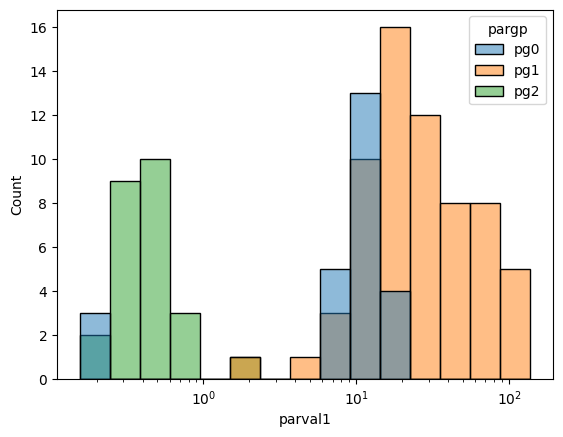

In [96]:
sns.histplot(data=pst.parameter_data, x='parval1', hue='pargp', bins=15, log_scale=True)

In [108]:
estimated_parameters = pst.parameter_data.copy()
10**(estimated_parameters.loc[estimated_parameters['partrans'] == 'log', 'parval1'])


parnme
p0     3.494053e+12
p1     3.494053e+12
p2     1.760332e+14
p3     4.922090e+06
p4     1.433442e+00
p5     3.494053e+12
p6     3.494053e+12
p7     1.760332e+14
p8     4.922090e+06
p9     1.433442e+00
p10    3.494053e+12
p11    3.494053e+12
p12    1.760332e+14
p13    4.922090e+06
p14    1.433442e+00
p15    1.578630e+13
p16    1.578630e+13
p17    3.840001e+13
p18    5.222278e+14
p19    1.468152e+10
p20    2.640122e+17
p21    2.640122e+17
p22    3.551992e+09
p23    2.149429e+06
p24    1.588320e+08
p25    6.541841e+01
p26    1.913024e+00
p27    1.913024e+00
p28    1.771136e+00
p29    1.678523e+00
p30    3.887908e+00
p31    1.987835e+00
p32    1.987835e+00
p33    2.330739e+00
p34    2.218620e+00
p35    3.018423e+00
p36    3.558680e+00
p37    3.558680e+00
p38    2.868029e+00
p39    1.739885e+00
p40    2.017756e+00
p41    3.512676e+00
p42    3.512676e+00
p43    3.368566e+00
p44    6.451585e+00
p45    7.007167e+00
p46    2.998685e+00
p47    2.998685e+00
p48    2.104079e+00
p49    8.1694

plotting head results

In [97]:
res_nz = pst.res.loc[pst.nnz_obs_names,:]
# display res_nz to understand what we are doing
res_nz.head(4)

,name,group,measured,modelled,residual,weight
name,,,,,,
ob0,ob0,obg0,0.005726,0.025209,-0.019483,1.0
ob1,ob1,obg0,0.016650,0.041023,-0.024373,1.0
ob2,ob2,obg0,0.033832,0.059626,-0.025794,1.0
ob3,ob3,obg0,0.050680,0.072293,-0.021613,1.0


<Figure size 800x1050 with 0 Axes>

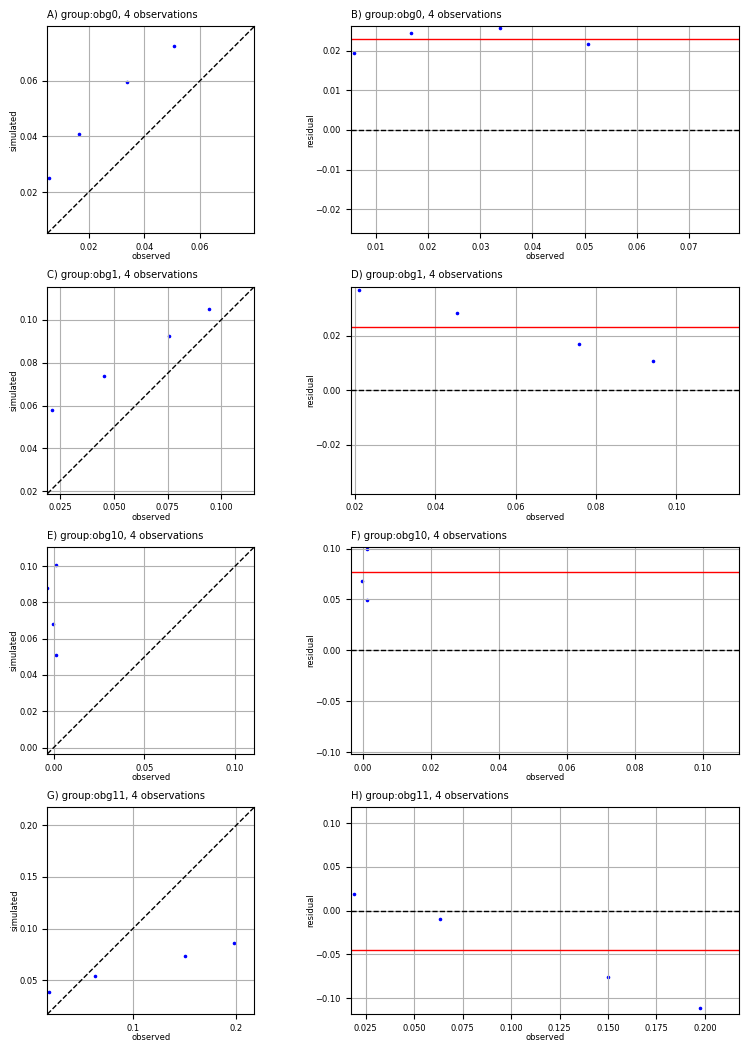

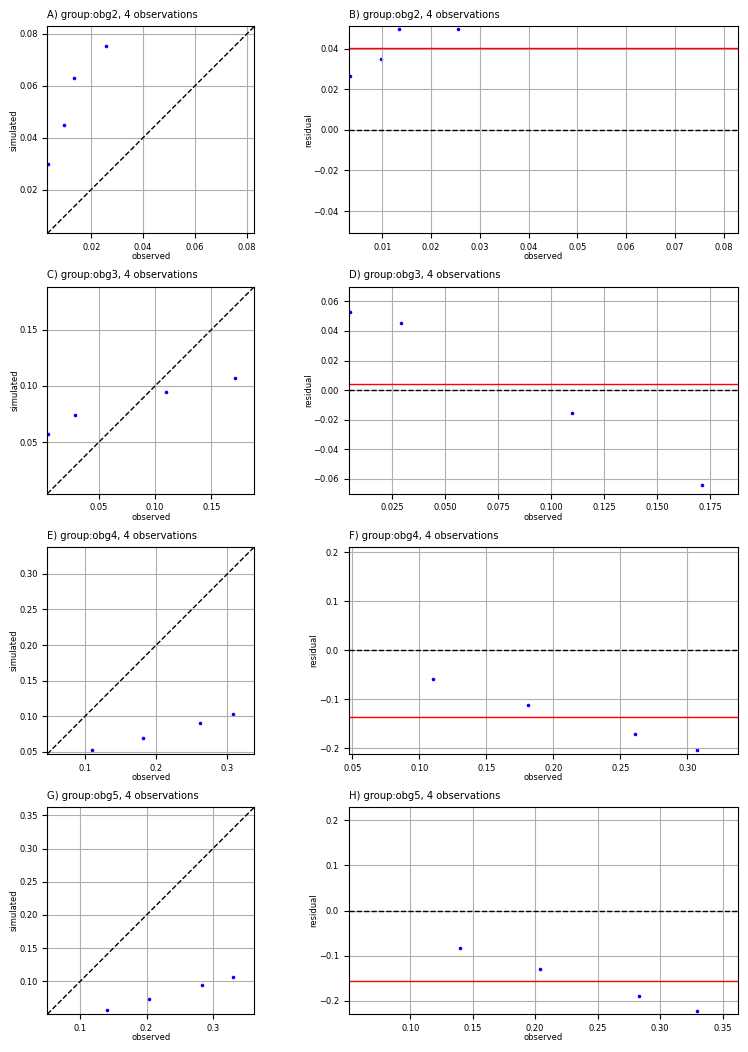

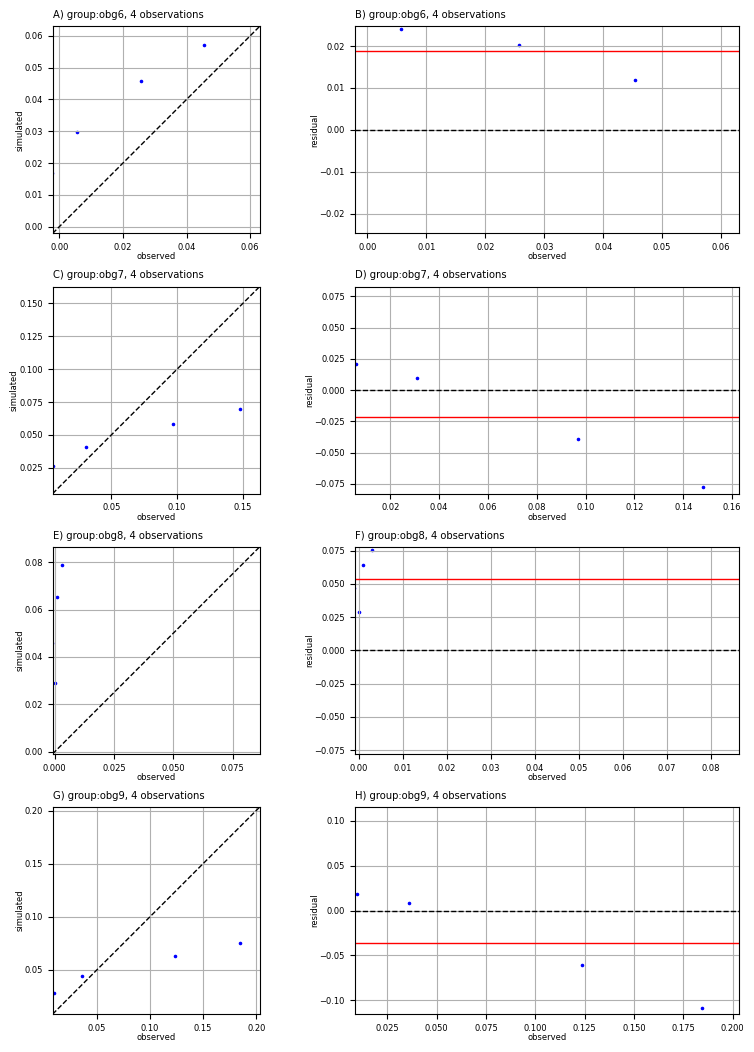

In [98]:
pyemu.plot_utils.res_1to1(pst);

In [99]:
pst.phi

np.float64(0.29840258761896993)

plotting estimated K field

In [100]:
sim = flopy.mf6.MFSimulation.load(sim_ws=m_d)
gwf = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


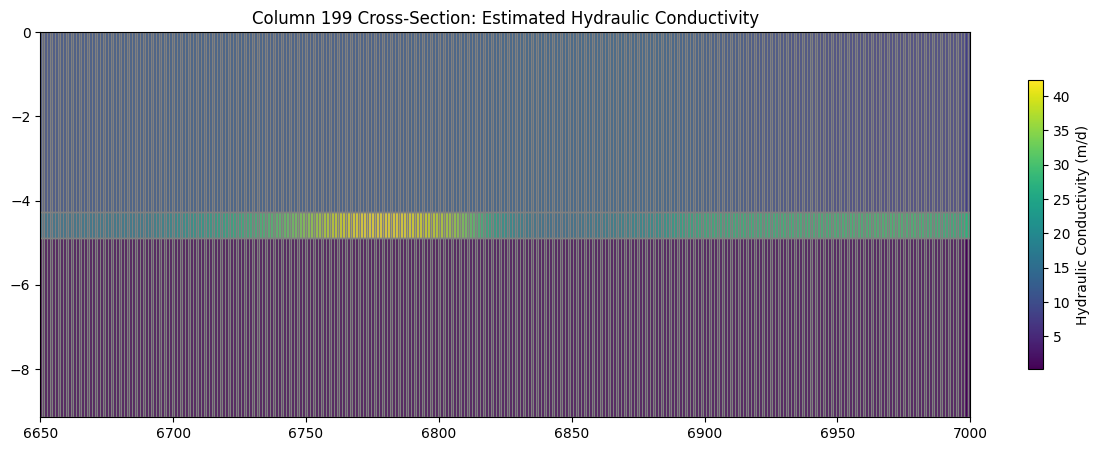

In [101]:
hk_array = gwf.npf.k.array

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1, 1, 1)

# Create a PlotCrossSection object for a specific column
xsect = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"Column": 199})

# Plot the hydraulic conductivity array on the cross-section
# The plot_array() method will display the values as colored patches
csa = xsect.plot_array(hk_array)

# Plot the model grid for context
linecollection = xsect.plot_grid()

# Add a color bar to interpret the hydraulic conductivity values
cb = plt.colorbar(csa, shrink=0.75, label="Hydraulic Conductivity (m/d)")

# Set the title and show the plot
ax.set_title("Column 199 Cross-Section: Estimated Hydraulic Conductivity")
ax.set_xlim(6650, 7000) # Assuming the same x-limits as your previous plot
plt.show()

whole field

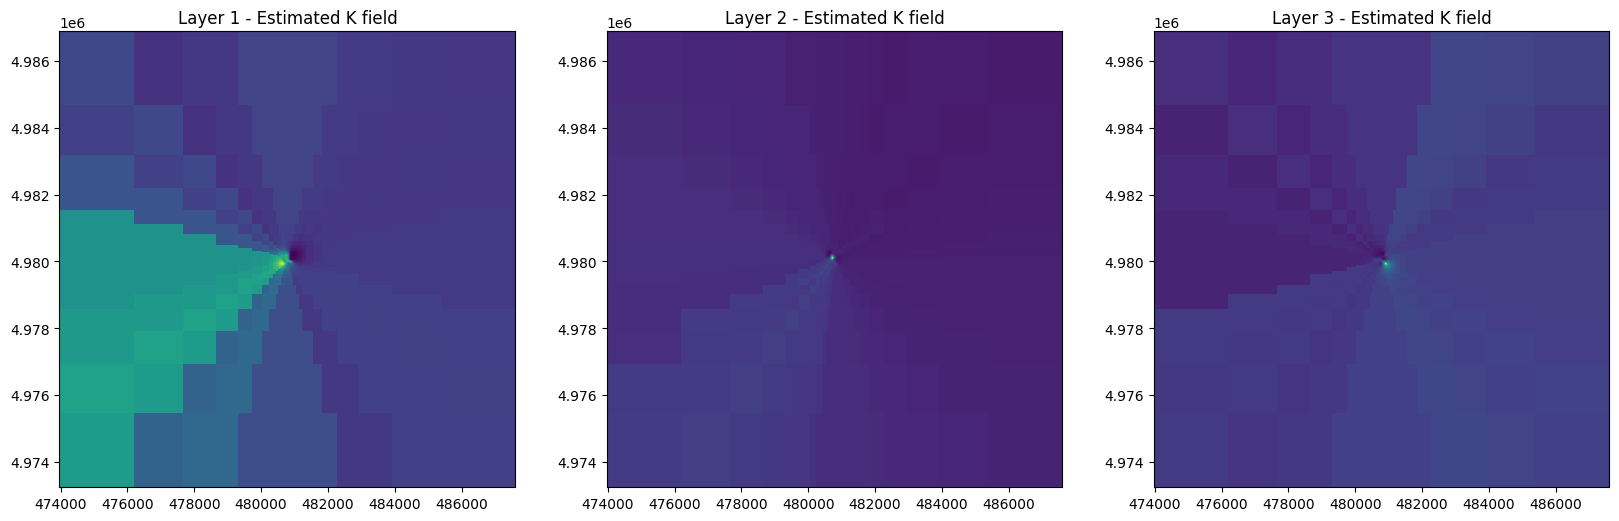

In [102]:
fig = plt.figure(figsize=(20, 20))
for i in range(3):
    
    ax = fig.add_subplot(1, 3, i+1, aspect='equal')

    # Create a PlotMapView object
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)

    # Plot the active and inactive cells
    # In MODFLOW 6, 'IDOMAIN' array is used instead of 'IBOUND'.
    # plot_ibound() handles this automatically.
    quadmesh = mapview.plot_array(hk_array[i]) # plots K field

    # Plot the grid lines for context
    #grid_lines = mapview.plot_grid()

    # Add a title and show the plot
    ax.set_title(f"Layer {i+1} - Estimated K field")
    #plt.show()

zoom at MLAC site

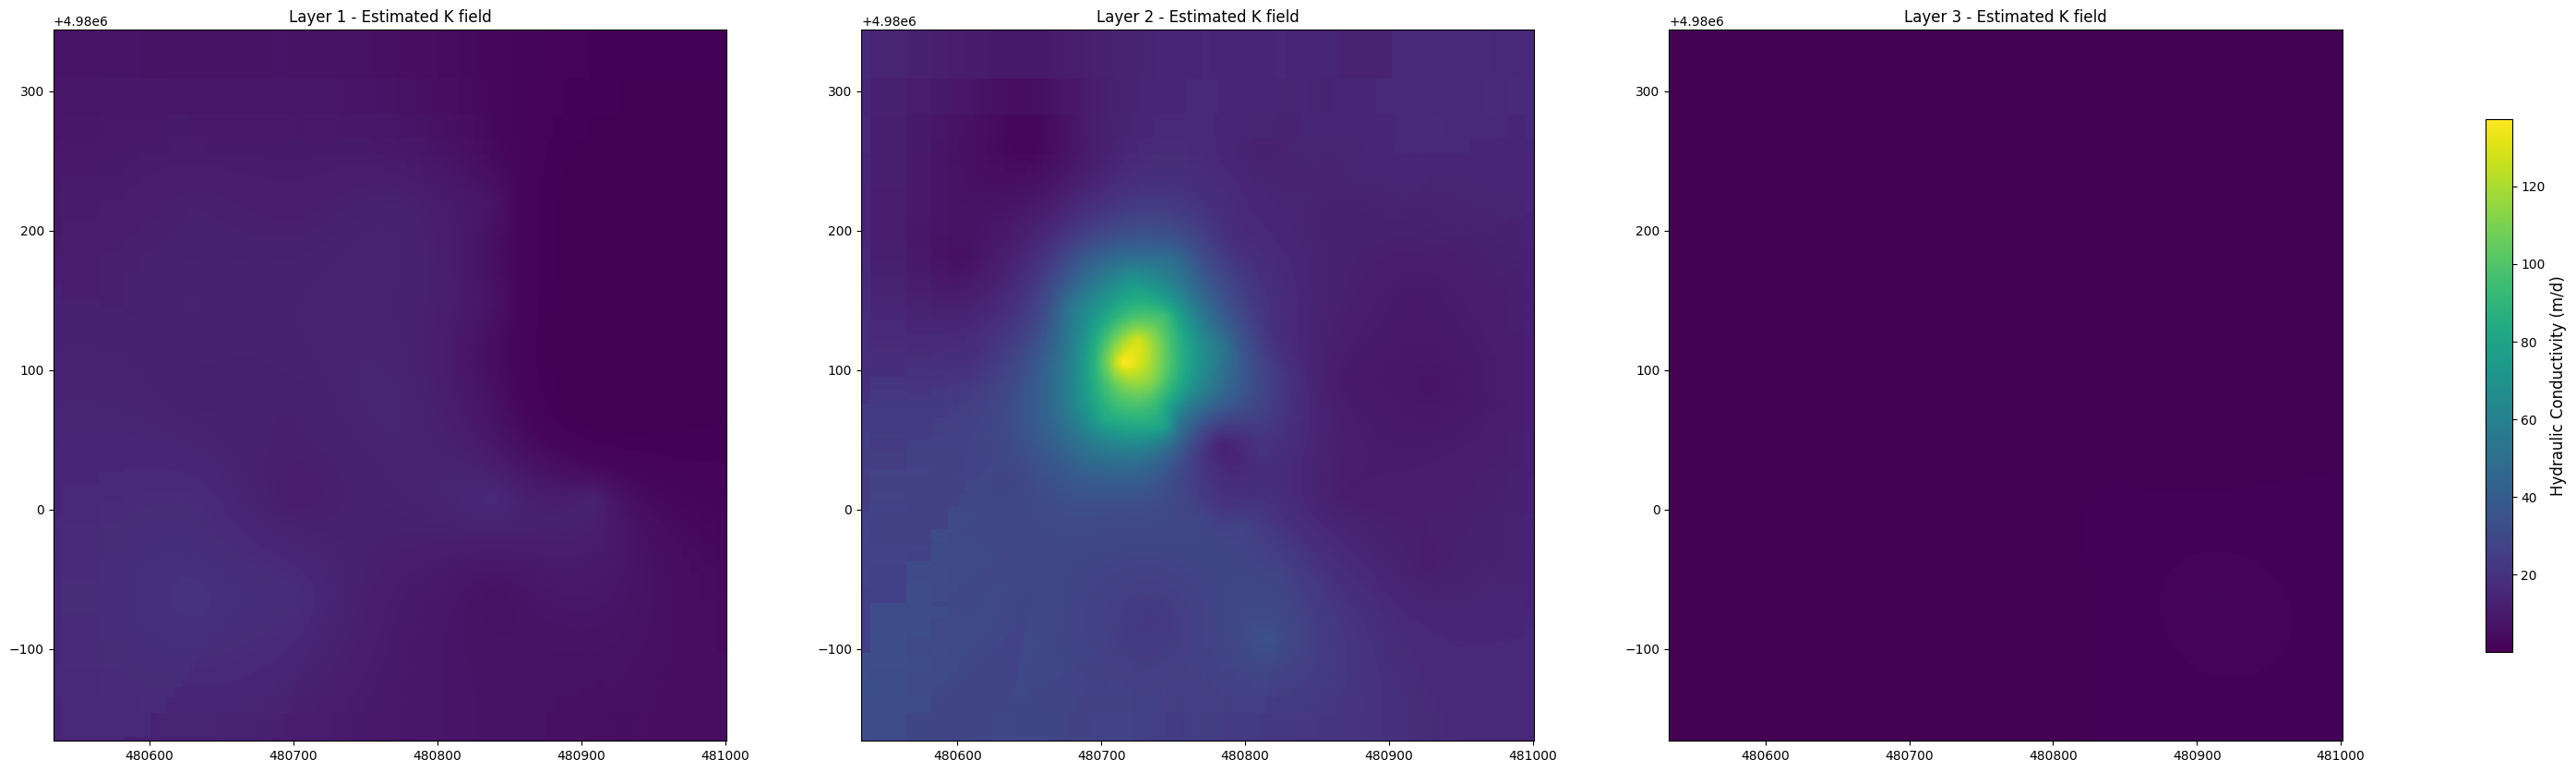

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
vmin = hk_array.min()
vmax = hk_array.max()

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    quadmesh = mapview.plot_array(hk_array[i], vmin=vmin, vmax=vmax)
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

In [104]:
from matplotlib.colors import LogNorm 

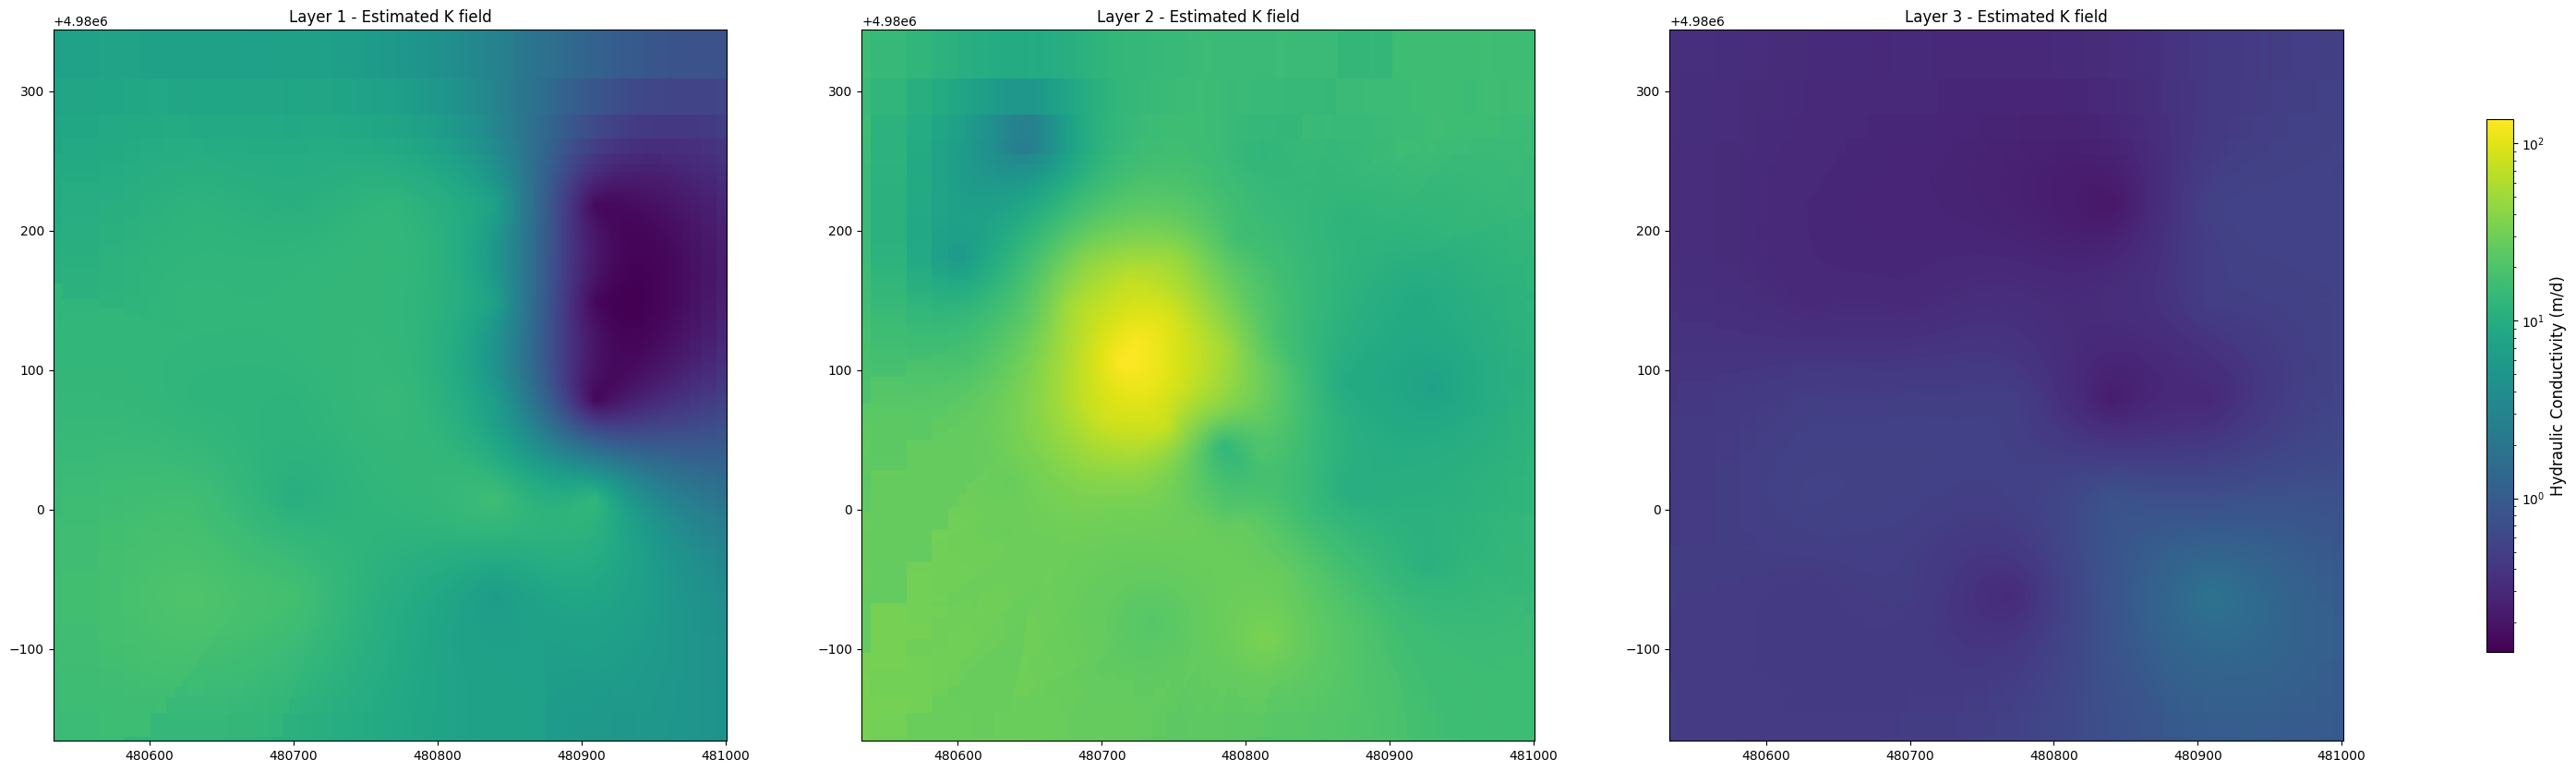

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
# These values MUST be positive for a log scale to work
vmin = hk_array.min()
vmax = hk_array.max()

# Ensure vmin is greater than 0, which hydraulic conductivity should be
if vmin <= 0:
    print(f"Warning: vmin ({vmin}) is <= 0. Adjusting to a small positive value for log scaling.")
    vmin = 1e-3 # Or some other appropriate small positive number

# Define the logarithmic normalization object
norm = LogNorm(vmin=vmin, vmax=vmax)

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    
    # Pass the 'norm' object to plot_array()
    quadmesh = mapview.plot_array(hk_array[i], norm=norm) 
    
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
# The colorbar automatically uses the norm associated with the quadmesh
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

debugging

In [1]:
import pathlib as pl 
import warnings
import flopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

c:\Users\lima0055\anaconda3\envs\gmdsitut\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
